# Phân tích Khám phá Dữ liệu (EDA) Không gian-Thời gian cho Lượng mưa (CHIRPS, 2019–2024)

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) chi tiết cho bộ dữ liệu mưa hàng ngày CHIRPS tại 13 tỉnh Đồng bằng sông Cửu Long (ĐBSCL) trong giai đoạn 2019–2024.


**Các tỉnh thành:** An Giang, Bến Tre, Cà Mau, Cần Thơ, Đồng Tháp, Hậu Giang, Kiên Giang, Long An, Sóc Trăng, Tiền Giang, Trà Vinh, Vĩnh Long, Bạc Liêu.

**Ký hiệu:**
-   `P_t(p)`: Lượng mưa (mm) tại tỉnh `p` vào ngày `t`.
-   Đợt khô hạn (Dry spell): Các ngày liên tiếp có `P_t = 0`.
-   Ngưỡng mưa cực đoan: Dựa trên phân vị (P95, P99) và giá trị tuyệt đối (≥50 mm, ≥100 mm).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import json
from scipy import stats
from statsmodels.tsa.seasonal import STL
from collections import defaultdict
import warnings

warnings.filterwarnings("ignore")

# Cài đặt style cho biểu đồ
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Đường dẫn file
DATA_DIR = Path("dataset") / "natural" / "precipitation"
CSV_PATH = DATA_DIR / "chirps_mekong_delta_2019_2024_full.csv"
META_PATH = DATA_DIR / "metadata.json"

np.random.seed(42)


# Các hàm tiện ích
def memory_usage(df: pd.DataFrame):
    """Tính toán dung lượng bộ nhớ của DataFrame (MB)."""
    return df.memory_usage(deep=True).sum() / 1024**2


def percent_missing(s: pd.Series):
    """Tính toán phần trăm giá trị thiếu."""
    return s.isna().mean() * 100


def run_length_encode_zero(series: pd.Series):
    """Mã hóa độ dài chuỗi các ngày không mưa (giá trị 0)."""
    lengths = []
    current = 0
    for v in series.values:
        if v == 0:
            current += 1
        else:
            if current > 0:
                lengths.append(current)
                current = 0
    if current > 0:
        lengths.append(current)
    return lengths


print("Cài đặt hoàn tất.")


Cài đặt hoàn tất.


In [ ]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Số dòng: {len(raw_df)}, Số cột: {raw_df.shape[1]}")
print("\n5 dòng đầu tiên:")
raw_df.head()


Số dòng: 28496, Số cột: 3

5 dòng đầu tiên:


,province,date,precipitation
0,Soc Trang,2019-01-01,8.083463
1,Soc Trang,2019-01-02,7.313124
2,Soc Trang,2019-01-03,2.128573
3,Soc Trang,2019-01-04,0.399126
4,Soc Trang,2019-01-05,0.000000


In [ ]:
print("\n5 dòng cuối cùng:")
raw_df.tail()



5 dòng cuối cùng:


,province,date,precipitation
28491,Tien Giang,2024-12-27,3.203309
28492,Tien Giang,2024-12-28,1.845928
28493,Tien Giang,2024-12-29,0.000000
28494,Tien Giang,2024-12-30,0.000000
28495,Tien Giang,2024-12-31,2.181505


In [ ]:
print(f"\nDung lượng bộ nhớ (MB): {memory_usage(raw_df):.2f}")
print(f"\nSố tỉnh thành duy nhất: {raw_df['province'].nunique()}")
print(f"Phạm vi ngày (thô): {raw_df['date'].min()} -> {raw_df['date'].max()}")



Dung lượng bộ nhớ (MB): 3.39

Số tỉnh thành duy nhất: 13
Phạm vi ngày (thô): 2019-01-01 -> 2024-12-31


## Kiểm tra Metadata & Đặc trưng

In [ ]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)
print("Metadata của đặc trưng:")
print(json.dumps(meta, indent=2, ensure_ascii=False))


Metadata của đặc trưng:
{
  "precipitation": {
    "unit": "mm",
    "description": "Lượng mưa hàng ngày"
  }
}


In [ ]:
assert set(raw_df.columns) == {"province", "date", "precipitation"}
print("\nKiểm tra tên cột thành công.")



Kiểm tra tên cột thành công.


## Chuyển đổi cột 'date' sang kiểu datetime

In [ ]:
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df = raw_df.sort_values(["province", "date"])


In [ ]:
raw_df


,province,date,precipitation
15344,An Giang,2019-01-01,1.821640
15345,An Giang,2019-01-02,8.387930
15346,An Giang,2019-01-03,1.354015
15347,An Giang,2019-01-04,3.177810
15348,An Giang,2019-01-05,0.000000
...,...,...,...
6571,Vinh Long,2024-12-27,0.000000
6572,Vinh Long,2024-12-28,0.095231
6573,Vinh Long,2024-12-29,0.000000
6574,Vinh Long,2024-12-30,0.000000


## Kiểm tra tính duy nhất của cặp (province, date)

In [ ]:
duplicates = raw_df.duplicated(subset=["province", "date"]).sum()
print(f"Số cặp (tỉnh, ngày) bị trùng lặp: {duplicates}")


Số cặp (tỉnh, ngày) bị trùng lặp: 0


## Kiểm tra tính toàn vẹn thời gian & Phát hiện khoảng trống

In [ ]:
all_dates = pd.date_range(raw_df["date"].min(), raw_df["date"].max(), freq="D")
province_gap_report = []
for prov, g in raw_df.groupby("province"):
    prov_dates = g["date"]
    missing = set(all_dates) - set(prov_dates)
    province_gap_report.append(
        {
            "Tỉnh": prov,
            "Số ngày kỳ vọng": len(all_dates),
            "Số ngày thực tế": len(prov_dates),
            "Số ngày thiếu": len(missing),
            "Tỷ lệ thiếu (%)": (len(missing) / len(all_dates)) * 100,
        }
    )

prov_gap_df = pd.DataFrame(province_gap_report)


In [74]:
print("\nBáo cáo dữ liệu thiếu theo tỉnh:")
prov_gap_df.sort_values("Số ngày thiếu", ascending=False)



Báo cáo dữ liệu thiếu theo tỉnh:


,Tỉnh,Số ngày kỳ vọng,Số ngày thực tế,Số ngày thiếu,Tỷ lệ thiếu (%)
0,An Giang,2192,2192,0,0.0
1,Bac Lieu,2192,2192,0,0.0
2,Ben Tre,2192,2192,0,0.0
3,Ca Mau,2192,2192,0,0.0
4,Can Tho city,2192,2192,0,0.0
5,Dong Thap,2192,2192,0,0.0
6,Hau Giang,2192,2192,0,0.0
7,Kien Giang,2192,2192,0,0.0
8,Long An,2192,2192,0,0.0
9,Soc Trang,2192,2192,0,0.0


## Biểu đồ heatmap về độ bao phủ dữ liệu

In [ ]:
pivot_cov = raw_df.assign(val=1).pivot_table(
    index="province", columns="date", values="val", fill_value=0
)
fig = px.imshow(
    pivot_cov,
    labels=dict(x="Ngày", y="Tỉnh", color="Hiện diện"),
    title="Biểu đồ Heatmap về độ bao phủ dữ liệu hàng ngày theo tỉnh",
    color_continuous_scale="Greens",
)
fig.update_layout(height=500)
fig.show()


## Phân tích giá trị thiếu & Ngày không mưa

In [ ]:
missing_pct = percent_missing(raw_df["precipitation"])
print(f"Tỷ lệ giá trị mưa bị thiếu: {missing_pct:.4f}%")


Tỷ lệ giá trị mưa bị thiếu: 0.0000%


## Thống kê ngày không mưa

In [77]:
zero_stats = (
    raw_df.assign(is_zero=(raw_df["precipitation"] == 0))
    .groupby("province")["is_zero"]
    .agg(["mean", "sum"])
)
zero_stats.rename(
    columns={"mean": "Tỷ lệ ngày không mưa", "sum": "Tổng số ngày không mưa"},
    inplace=True,
)
print("\nThống kê ngày không mưa theo tỉnh:")
zero_stats.sort_values("Tỷ lệ ngày không mưa", ascending=False)



Thống kê ngày không mưa theo tỉnh:


,Tỷ lệ ngày không mưa,Tổng số ngày không mưa
province,,
Vinh Long,0.369526,810
Tra Vinh,0.358120,785
Ben Tre,0.354015,776
Can Tho city,0.344891,756
Hau Giang,0.336223,737
Tien Giang,0.326186,715
Soc Trang,0.322080,706
Bac Lieu,0.312500,685
An Giang,0.298358,654


## Phân phối độ dài các đợt khô hạn

In [78]:
spell_summary = []
for prov, g in raw_df.groupby("province"):
    lengths = run_length_encode_zero(g["precipitation"])
    if lengths:
        spell_summary.append(
            {
                "Tỉnh": prov,
                "Số đợt khô hạn": len(lengths),
                "Đợt dài nhất (ngày)": max(lengths),
                "Độ dài trung bình (ngày)": np.mean(lengths),
            }
        )
spell_df = pd.DataFrame(spell_summary).sort_values(
    "Đợt dài nhất (ngày)", ascending=False
)
print("\nThống kê các đợt khô hạn theo tỉnh:")
spell_df



Thống kê các đợt khô hạn theo tỉnh:


,Tỉnh,Số đợt khô hạn,Đợt dài nhất (ngày),Độ dài trung bình (ngày)
5,Dong Thap,225,44,2.853333
2,Ben Tre,245,38,3.167347
4,Can Tho city,244,37,3.098361
12,Vinh Long,240,37,3.375000
10,Tien Giang,239,31,2.991632
6,Hau Giang,246,25,2.995935
0,An Giang,243,20,2.691358
11,Tra Vinh,243,19,3.230453
1,Bac Lieu,236,17,2.902542
9,Soc Trang,254,17,2.779528


In [79]:
fig = px.histogram(
    spell_df,
    x="Đợt dài nhất (ngày)",
    nbins=20,
    title="Phân phối độ dài đợt khô hạn dài nhất (cấp tỉnh)",
    labels={"x": "Số ngày", "count": "Số tỉnh"},
)
fig.show()


## Phát hiện ngoại lệ & Sự kiện mưa lớn

In [ ]:
p95 = raw_df["precipitation"].quantile(0.95)
p99 = raw_df["precipitation"].quantile(0.99)
thresholds = {"P95": p95, "P99": p99, "50mm": 50, "100mm": 100}
print("\nNgưỡng mưa cực đoan:")
print(thresholds)



Ngưỡng mưa cực đoan:
{'P95': np.float64(19.797346283766792), 'P99': np.float64(31.913769305086554), '50mm': 50, '100mm': 100}


## Tổng số ngày mưa cực đoan

In [81]:
extreme_records = []
for name, thr in thresholds.items():
    count = (raw_df["precipitation"] >= thr).sum()
    extreme_records.append(
        {"Loại ngưỡng": name, "Giá trị ngưỡng (mm)": thr, "Số ngày vượt ngưỡng": count}
    )
print("\nTổng số ngày mưa cực đoan trên toàn bộ dữ liệu:")
pd.DataFrame(extreme_records)



Tổng số ngày mưa cực đoan trên toàn bộ dữ liệu:


,Loại ngưỡng,Giá trị ngưỡng (mm),Số ngày vượt ngưỡng
0,P95,19.797346,1425
1,P99,31.913769,285
2,50mm,50.000000,29
3,100mm,100.000000,0


In [82]:
raw_df["year"] = raw_df["date"].dt.year

extreme_timeline = (
    raw_df.groupby("year")
    .agg(
        total_extreme_p95=("precipitation", lambda s: (s >= p95).sum()),
        total_extreme_p99=("precipitation", lambda s: (s >= p99).sum()),
        days_ge_50mm=("precipitation", lambda s: (s >= 50).sum()),
        days_ge_100mm=("precipitation", lambda s: (s >= 100).sum()),
    )
    .reset_index()
)

fig = px.line(
    extreme_timeline,
    x="year",
    y=["total_extreme_p95", "total_extreme_p99", "days_ge_50mm", "days_ge_100mm"],
    title="Số ngày mưa cực đoan hàng năm",
    labels={"year": "Năm", "value": "Số ngày", "variable": "Loại ngưỡng"},
    markers=True,
)
fig.show()


## Phân phối đơn biến & Hành vi vùng đuôi

In [ ]:
vals = raw_df["precipitation"].dropna()
fig = go.Figure()
fig.add_trace(go.Histogram(x=vals, name="Phân phối tuyến tính", nbinsx=100))
fig.update_layout(
    title_text="Phân phối lượng mưa hàng ngày (Thang đo tuyến tính)",
    xaxis_title_text="Lượng mưa (mm)",
    yaxis_title_text="Số ngày",
)
fig.show()


In [ ]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=vals[vals > 0], name="Phân phối Log", nbinsx=100))
fig.update_layout(
    title_text="Phân phối lượng mưa hàng ngày (Chỉ giá trị > 0, Thang đo Log)",
    xaxis_title_text="Lượng mưa (mm)",
    yaxis_title_text="Số ngày (Log)",
    yaxis_type="log",
)
fig.show()


# QQ plot so với phân phối Gamma

In [85]:
shape, loc, scale = stats.gamma.fit(vals[vals > 0], floc=0)
print(f"Tham số phân phối Gamma: shape={shape:.3f}, scale={scale:.3f}")


Tham số phân phối Gamma: shape=0.601, scale=11.902


In [86]:
quantiles = np.linspace(0.01, 0.99, 100)
emp_q = np.quantile(vals[vals > 0], quantiles)
model_q = stats.gamma.ppf(quantiles, a=shape, loc=0, scale=scale)

fig = go.Figure()
fig.add_trace(go.Scatter(x=model_q, y=emp_q, mode="markers", name="Dữ liệu"))
fig.add_trace(
    go.Scatter(
        x=[model_q.min(), model_q.max()],
        y=[model_q.min(), model_q.max()],
        mode="lines",
        name="Đường tham chiếu",
        line=dict(dash="dash"),
    )
)
fig.update_layout(
    title_text="Biểu đồ Q-Q so với phân phối Gamma",
    xaxis_title_text="Phân vị lý thuyết (Gamma)",
    yaxis_title_text="Phân vị thực tế",
)
fig.show()

print(f"Độ xiên (Skewness): {stats.skew(vals):.3f}")
print(f"Độ nhọn (Kurtosis): {stats.kurtosis(vals):.3f}")


Độ xiên (Skewness): 2.227
Độ nhọn (Kurtosis): 6.813


## Xu hướng thời gian, Tính thời vụ & Đặc điểm gió mùa

In [ ]:
prov_daily_mean = raw_df.groupby("date")["precipitation"].mean()
rolling30 = prov_daily_mean.rolling(30, min_periods=7).mean()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=prov_daily_mean.index,
        y=prov_daily_mean.values,
        mode="lines",
        name="Trung bình ngày",
        line=dict(width=0.5, color="rgba(0, 0, 255, 0.5)"),
    )
)
fig.add_trace(
    go.Scatter(
        x=rolling30.index,
        y=rolling30.values,
        mode="lines",
        name="Trung bình trượt 30 ngày",
        line=dict(color="red"),
    )
)
fig.update_layout(
    title_text="Lượng mưa trung bình ngày vs. Trung bình trượt 30 ngày (trên tất cả các tỉnh)",
    xaxis_title_text="Ngày",
    yaxis_title_text="Lượng mưa (mm)",
)
fig.show()


## Tổng lượng mưa trung bình hàng tháng (trên tất cả các tỉnh)

In [88]:
monthly = (
    raw_df.set_index("date")
    .groupby("province")["precipitation"]
    .resample("M")
    .sum()
    .reset_index()
)
monthly_total = monthly.groupby("date")["precipitation"].mean()

fig = px.line(
    monthly_total.reset_index(),
    x="date",
    y="precipitation",
    markers=True,
    title="Tổng lượng mưa trung bình hàng tháng (trên tất cả các tỉnh)",
    labels={"date": "Tháng", "precipitation": "Tổng lượng mưa (mm)"},
)
fig.show()


## Khí hậu học nền 2019-2023

In [89]:
base = raw_df[raw_df["year"] <= 2023].copy()
base["doy"] = base["date"].dt.dayofyear
climatology = base.groupby("doy")["precipitation"].mean()
current = raw_df.copy()
current["doy"] = current["date"].dt.dayofyear
current_mean = current.groupby("doy")["precipitation"].mean()
anomaly = current_mean - climatology

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=climatology.index, y=climatology.values, name="Khí hậu học (2019-23)")
)
fig.add_trace(
    go.Scatter(
        x=current_mean.index,
        y=current_mean.values,
        name="Trung bình (2019-24)",
        line=dict(dash="dot"),
    )
)
fig.add_trace(
    go.Bar(
        x=anomaly.index,
        y=anomaly.values,
        name="Bất thường",
        marker_color="rgba(255, 0, 0, 0.5)",
    )
)
fig.update_layout(
    title_text="Khí hậu học hàng ngày & Bất thường (Trung bình trên các tỉnh)",
    xaxis_title_text="Ngày trong năm (Day of Year)",
    yaxis_title_text="Lượng mưa (mm)",
)
fig.show()


## Tương phản mưa theo không gian (tỉnh)

In [90]:
yearly = raw_df.groupby(["province", "year"])["precipitation"].sum().reset_index()
fig = px.line(
    yearly,
    x="year",
    y="precipitation",
    color="province",
    title="Tổng lượng mưa hàng năm theo tỉnh",
    labels={"year": "Năm", "precipitation": "Tổng lượng mưa (mm)"},
)
fig.show()

fig = px.box(
    raw_df,
    x="province",
    y="precipitation",
    title="Phân phối lượng mưa hàng ngày theo tỉnh",
    labels={"province": "Tỉnh", "precipitation": "Lượng mưa (mm)"},
)
fig.update_xaxes(tickangle=45)
fig.show()


## Phân tích bổ sung Mưa vs. Thời gian (Tháng, Mùa, Năm)

In [ ]:
# Tạo các biến thời gian nếu chưa có
if "month" not in raw_df.columns:
    raw_df["month"] = raw_df["date"].dt.month

if "season" not in raw_df.columns:
    raw_df["season"] = np.select(
        [
            raw_df["month"].isin([5, 6, 7, 8, 9, 10]),
            raw_df["month"].isin([11, 12, 1, 2, 3, 4]),
        ],
        ["Mùa mưa", "Mùa khô"],
        "Chuyển tiếp",
    )

if "year" not in raw_df.columns:
    raw_df["year"] = raw_df["date"].dt.year


## Lượng mưa hàng ngày theo Tháng

In [ ]:
fig = px.box(
    raw_df,
    x="month",
    y="precipitation",
    title="Phân phối lượng mưa hàng ngày theo Tháng",
    labels={"month": "Tháng", "precipitation": "Lượng mưa (mm)"},
)
fig.show()


## Lượng mưa hàng ngày theo Mùa

In [ ]:
fig = px.box(
    raw_df,
    x="season",
    y="precipitation",
    title="Phân phối lượng mưa hàng ngày theo Mùa",
    labels={"season": "Mùa", "precipitation": "Lượng mưa (mm)"},
    category_orders={"season": ["Mùa khô", "Mùa mưa", "Chuyển tiếp"]},
)
fig.show()


## Lượng mưa hàng ngày theo Năm

In [ ]:
fig = px.box(
    raw_df,
    x="year",
    y="precipitation",
    title="Phân phối lượng mưa hàng ngày theo Năm",
    labels={"year": "Năm", "precipitation": "Lượng mưa (mm)"},
)
fig.show()


### Phân tích Đơn biến (Univariate Analysis)
Phần này tập trung vào việc khám phá từng biến một cách riêng lẻ.
- **Biến số (Numerical):** `precipitation`.
- **Biến phân loại (Categorical):** `province`, và các biến thời gian như `year`, `month`, `season`.


## Tổng hợp dữ liệu (Theo tuần/tháng/mùa)

In [ ]:
prec = raw_df.copy()
prec["pentad"] = (prec["date"].dt.dayofyear - 1) // 5 + 1
prec["month"] = prec["date"].dt.month
prec["season"] = np.select(
    [prec["month"].isin([5, 6, 7, 8, 9, 10]), prec["month"].isin([11, 12, 1, 2, 3, 4])],
    ["Mùa mưa", "Mùa khô"],
    "Chuyển tiếp",
)

pentad_sum = (
    prec.groupby(["province", "year", "pentad"])["precipitation"].sum().reset_index()
)
monthly_sum = (
    prec.groupby(["province", "year", "month"])["precipitation"].sum().reset_index()
)
season_sum = (
    prec.groupby(["province", "year", "season"])["precipitation"].sum().reset_index()
)
print(
    f"Số dòng theo pentad: {len(pentad_sum)}, theo tháng: {len(monthly_sum)}, theo mùa: {len(season_sum)}"
)


Số dòng theo pentad: 5720, theo tháng: 936, theo mùa: 156


## Biến thiên giữa các năm (CV) của tổng lượng mưa mùa mưa theo tỉnh

In [ ]:
wet_totals = (
    season_sum[season_sum["season"] == "Mùa mưa"]
    .groupby("province")["precipitation"]
    .agg(["mean", "std"])
)
wet_totals["cv"] = wet_totals["std"] / wet_totals["mean"]
print("\nHệ số biến thiên (CV) tổng mưa mùa mưa theo tỉnh:")
wet_totals.sort_values("cv", ascending=False)



Hệ số biến thiên (CV) tổng mưa mùa mưa theo tỉnh:


,mean,std,cv
province,,,
Tra Vinh,1417.534855,206.318501,0.145547
Ben Tre,1316.495323,173.332145,0.131662
Ca Mau,1884.896019,231.787319,0.122971
Soc Trang,1637.860657,200.904308,0.122663
Bac Lieu,1777.342061,198.456990,0.111659
Vinh Long,1412.239009,142.634250,0.100999
Kien Giang,1761.298180,157.344648,0.089334
Hau Giang,1648.722222,134.787763,0.081753
Tien Giang,1350.370174,109.791822,0.081305


## Bất thường so với Khí hậu học (Heatmap Tỉnh x Ngày trong năm)

In [ ]:
prec["doy"] = prec["date"].dt.dayofyear
clim_prov = (
    prec[prec["year"] <= 2023]
    .groupby(["province", "doy"])["precipitation"]
    .mean()
    .rename("clim")
)
merged = prec.set_index(["province", "doy"]).join(clim_prov).reset_index()
merged["anomaly"] = merged["precipitation"] - merged["clim"]
heat = merged.pivot_table(
    index="province", columns="doy", values="anomaly", aggfunc="mean"
)

fig = px.imshow(
    heat,
    labels=dict(x="Ngày trong năm", y="Tỉnh", color="Bất thường (mm)"),
    title="Heatmap Bất thường Lượng mưa (Tỉnh x Ngày trong năm)",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
)
fig.update_layout(height=600)
fig.show()


## Biến thiên không gian & Tính đồng bộ (Tương quan cặp)

In [98]:
pivot_daily = prec.pivot_table(index="date", columns="province", values="precipitation")
cor_mat = pivot_daily.corr(method="pearson")

fig = px.imshow(
    cor_mat,
    labels=dict(x="Tỉnh", y="Tỉnh", color="Tương quan"),
    title="Tương quan Pearson cặp của lượng mưa hàng ngày giữa các tỉnh",
    color_continuous_scale="Viridis",
)
fig.update_layout(height=600)
fig.show()


## Phân rã chuỗi thời gian (STL) (Trung bình các tỉnh)

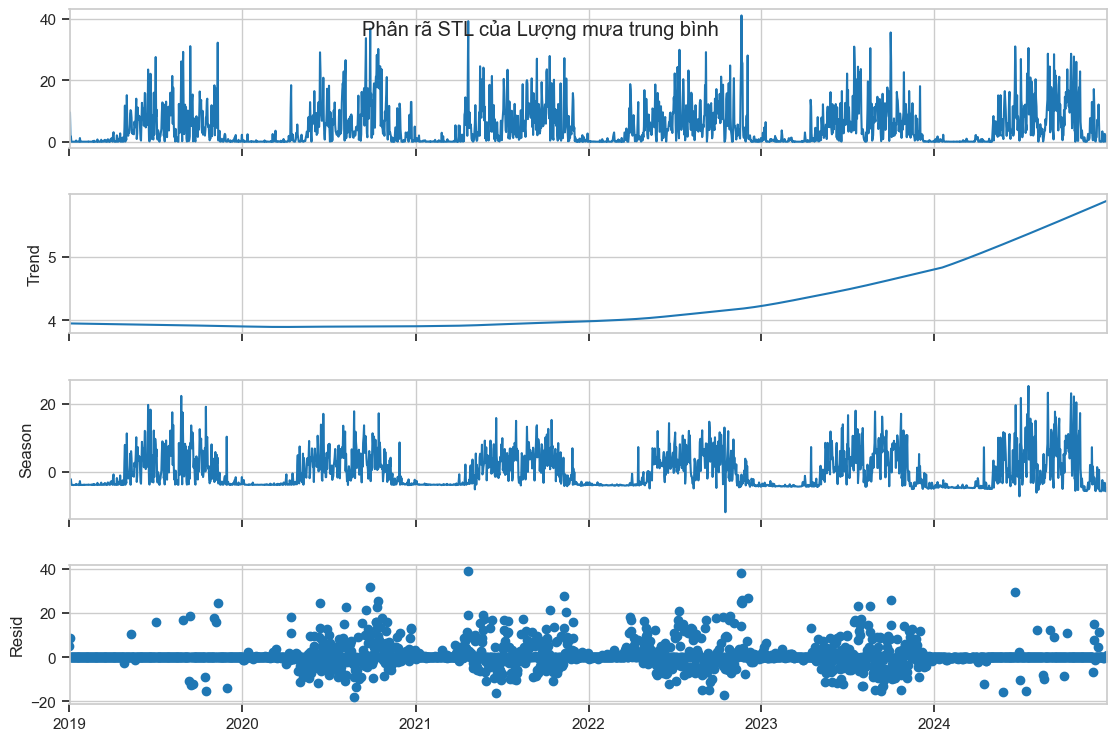

In [99]:
series = pivot_daily.mean(axis=1).dropna()
stl = STL(series, period=365, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Phân rã STL của Lượng mưa trung bình", y=0.95)
plt.show()


### Phân tích Hai biến (Bivariate Analysis)

Phần này khám phá mối quan hệ giữa hai biến.

- **Số - Số (Numerical - Numerical):** Mối quan hệ giữa lượng mưa theo thời gian (xu hướng, mùa vụ).
- **Số - Phân loại (Numerical - Categorical):** So sánh lượng mưa (`precipitation`) giữa các `province`, `year`, `month`, `season`.


In [100]:
# Tạo các biến thời gian nếu chưa có
if "month" not in raw_df.columns:
    raw_df["month"] = raw_df["date"].dt.month
if "season" not in raw_df.columns:
    raw_df["season"] = np.select(
        [
            raw_df["month"].isin([5, 6, 7, 8, 9, 10]),
            raw_df["month"].isin([11, 12, 1, 2, 3, 4]),
        ],
        ["Mùa mưa", "Mùa khô"],
        "Chuyển tiếp",
    )


# 1. Số - Số (Numerical - Numerical): Mối quan hệ giữa lượng mưa theo thời gian

## Lượng mưa vs Ngày trong năm

In [101]:
raw_df["day_of_year"] = raw_df["date"].dt.dayofyear
sample_data = raw_df.sample(n=5000, random_state=42)  # Lấy mẫu để tránh quá tải

fig = px.scatter(
    sample_data,
    x="day_of_year",
    y="precipitation",
    title="Mối quan hệ giữa Lượng mưa và Ngày trong năm",
    labels={"day_of_year": "Ngày trong năm (1-365)", "precipitation": "Lượng mưa (mm)"},
    opacity=0.6,
)
fig.add_hline(
    y=raw_df["precipitation"].mean(),
    line_dash="dash",
    line_color="red",
    annotation_text=f"Trung bình: {raw_df['precipitation'].mean():.2f}mm",
)
fig.show()


# 2. Số - Phân loại (Numerical - Categorical): So sánh lượng mưa theo các nhóm

## Lượng mưa theo Tháng

In [102]:
fig = px.box(
    raw_df,
    x="month",
    y="precipitation",
    title="Phân phối lượng mưa theo Tháng",
    labels={"month": "Tháng", "precipitation": "Lượng mưa (mm)"},
)
fig.show()


## Lượng mưa theo Mùa

In [103]:
fig = px.box(
    raw_df,
    x="season",
    y="precipitation",
    title="Phân phối lượng mưa theo Mùa",
    labels={"season": "Mùa", "precipitation": "Lượng mưa (mm)"},
    category_orders={"season": ["Mùa khô", "Mùa mưa", "Chuyển tiếp"]},
)
fig.show()


## Lượng mưa theo Năm

In [104]:
fig = px.box(
    raw_df,
    x="year",
    y="precipitation",
    title="Phân phối lượng mưa theo Năm",
    labels={"year": "Năm", "precipitation": "Lượng mưa (mm)"},
)
fig.show()


## Lượng mưa theo Tỉnh 
- (cho thấy phân phối chi tiết hơn)

In [105]:
fig = px.violin(
    raw_df,
    x="province",
    y="precipitation",
    title="Phân phối lượng mưa theo Tỉnh (Violin Plot)",
    labels={"province": "Tỉnh", "precipitation": "Lượng mưa (mm)"},
)
fig.update_xaxes(tickangle=45)
fig.show()


### Phân tích Đa biến (Multivariate Analysis)

Phần này khám phá mối quan hệ giữa ba hoặc nhiều biến.

- **Tương quan không gian:** Phân tích tương quan giữa lượng mưa của các tỉnh khác nhau để xem chúng có xu hướng mưa đồng thời hay không.
- **Phân rã chuỗi thời gian:** Tách chuỗi thời gian thành các thành phần xu hướng, mùa vụ và phần dư để hiểu các động lực cơ bản.


## Số ngày mưa cực đoan (>P95) theo Tỉnh và Năm

In [106]:
extreme_days_p95 = (
    raw_df[raw_df["precipitation"] > p95]
    .groupby(["province", "year"])
    .size()
    .unstack(fill_value=0)
)

fig = px.imshow(
    extreme_days_p95,
    labels=dict(x="Năm", y="Tỉnh", color="Số ngày mưa > P95"),
    title="Heatmap số ngày mưa cực đoan (>P95) theo Tỉnh và Năm",
    color_continuous_scale="Reds",
)
fig.show()


## Tổng lượng mưa theo Tỉnh và Tháng

In [107]:
monthly_sum_pivot = (
    raw_df.groupby(["province", "month"])["precipitation"].sum().unstack()
)

fig = px.imshow(
    monthly_sum_pivot,
    labels=dict(x="Tháng", y="Tỉnh", color="Tổng lượng mưa (mm)"),
    title="Heatmap tổng lượng mưa theo Tỉnh và Tháng",
    color_continuous_scale="Blues",
)
fig.show()


# Phân tích Đa biến (Multivariate Analysis)

## Số ngày mưa cực đoan (>P95) theo Tỉnh và Năm

In [108]:
extreme_days_p95 = (
    raw_df[raw_df["precipitation"] > p95]
    .groupby(["province", "year"])
    .size()
    .unstack(fill_value=0)
)

fig = px.imshow(
    extreme_days_p95,
    labels=dict(x="Năm", y="Tỉnh", color="Số ngày mưa > P95"),
    title="Heatmap số ngày mưa cực đoan (>P95) theo Tỉnh và Năm",
    color_continuous_scale="Reds",
)
fig.update_layout(height=600)
fig.show()


## Tổng lượng mưa theo Tỉnh và Tháng

In [109]:
monthly_sum_pivot = (
    raw_df.groupby(["province", "month"])["precipitation"].sum().unstack()
)

fig = px.imshow(
    monthly_sum_pivot,
    labels=dict(x="Tháng", y="Tỉnh", color="Tổng lượng mưa (mm)"),
    title="Heatmap tổng lượng mưa theo Tỉnh và Tháng",
    color_continuous_scale="Blues",
)
fig.update_layout(height=600)
fig.show()


## Phân tích Tương quan không gian: Ma trận tương quan giữa các tỉnh

In [110]:
pivot_daily = raw_df.pivot_table(
    index="date", columns="province", values="precipitation"
)
cor_mat = pivot_daily.corr(method="pearson")

# Biểu đồ ma trận tương quan
fig = px.imshow(
    cor_mat,
    labels=dict(x="Tỉnh", y="Tỉnh", color="Hệ số tương quan"),
    title="Ma trận tương quan lượng mưa hàng ngày giữa các tỉnh",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
)
fig.update_layout(height=600)
fig.show()


## các cặp tỉnh có tương quan cao nhất và thấp nhất|

In [111]:
cor_values = []
for i in range(len(cor_mat.columns)):
    for j in range(i + 1, len(cor_mat.columns)):
        cor_values.append(
            {
                "Tỉnh 1": cor_mat.columns[i],
                "Tỉnh 2": cor_mat.columns[j],
                "Tương quan": cor_mat.iloc[i, j],
            }
        )

cor_df = pd.DataFrame(cor_values).sort_values("Tương quan", ascending=False)
cor_df


,Tỉnh 1,Tỉnh 2,Tương quan
4,An Giang,Dong Thap,0.936125
13,Bac Lieu,Ca Mau,0.927992
69,Long An,Tien Giang,0.925302
73,Soc Trang,Tra Vinh,0.922972
19,Bac Lieu,Soc Trang,0.920626
...,...,...,...
23,Ben Tre,Ca Mau,0.647054
18,Bac Lieu,Long An,0.641367
34,Ca Mau,Dong Thap,0.634902
39,Ca Mau,Tien Giang,0.624872


In [112]:
print("Top 5 cặp tỉnh có tương quan mưa cao nhất:")
cor_df.head()


Top 5 cặp tỉnh có tương quan mưa cao nhất:


,Tỉnh 1,Tỉnh 2,Tương quan
4,An Giang,Dong Thap,0.936125
13,Bac Lieu,Ca Mau,0.927992
69,Long An,Tien Giang,0.925302
73,Soc Trang,Tra Vinh,0.922972
19,Bac Lieu,Soc Trang,0.920626


In [113]:
print("\nTop 5 cặp tỉnh có tương quan mưa thấp nhất:")
cor_df.tail()



Top 5 cặp tỉnh có tương quan mưa thấp nhất:


,Tỉnh 1,Tỉnh 2,Tương quan
23,Ben Tre,Ca Mau,0.647054
18,Bac Lieu,Long An,0.641367
34,Ca Mau,Dong Thap,0.634902
39,Ca Mau,Tien Giang,0.624872
37,Ca Mau,Long An,0.602535


## Phân tích thống kê theo nhóm: Mưa cực đoan theo Tỉnh và Mùa

In [114]:
extreme_by_province_season = (
    raw_df[raw_df["precipitation"] > p95]
    .groupby(["province", "season"])
    .size()
    .unstack(fill_value=0)
)

fig = px.imshow(
    extreme_by_province_season,
    labels=dict(x="Mùa", y="Tỉnh", color="Số ngày mưa cực đoan"),
    title="Heatmap số ngày mưa cực đoan theo Tỉnh và Mùa",
    color_continuous_scale="Oranges",
)
fig.update_layout(height=600)
fig.show()
